Instructions
Objective:
To build a time sequence model for predicting short term future stock prices from historical data.

Data:
Historical stock price data on US-based stocks, last updated in 2017. The dataset is available at Huge Stock Market Dataset | Kaggle and is provided by Boris Marjanovic. A list of stock ticker symbols is available at List of All Stock Ticker Symbols - Stock Analysis, to help identify the name of the stock from the txt file name.

Problem Statement:
An investment company is interested in learning about the potential profit in frequent buy/sell stock transactions. You are tasked with developing a time sequence model to predict the price two days ahead based on recent prices. Choose four (or more) of the data files for training and a separate two for validation. Once the model is finalized, demonstrate how well your model makes predictions by using two other data files for testing.

Steps to be completed:
Create a Jupyter notebook and complete the following steps:


In [81]:
import pandas as pd
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

### Data
A) Select four (or more) of the data files in stocks.zip to use as training data, two others for validation, and two others for testing.

In [82]:

# training_csv = ['amn.us.csv', 'bspm.us.csv', 'hqcl.us.csv', 'ifn.us.csv']
# val_csv    = ['jhme.us.csv', 'vno_l.us.csv']
# test_csv = ['vmo.us.csv', 'ziop.us.csv']

# training_df = pd.DataFrame(columns=['Date','Open','High','Low','Close','Volume','OpenInt'])
# val_df = pd.DataFrame(columns=['Date','Open','High','Low','Close','Volume','OpenInt'])
# test_df = pd.DataFrame(columns=['Date','Open','High','Low','Close','Volume','OpenInt'])
# dfs = {}

# for i in training_csv:
#     url = f"https://raw.githubusercontent.com/Hunteracademic/Neural_network_group_7/master/stocks_folder/Stocks/{i}"
#     df = pd.read_csv(url)
#     training_df = pd.concat([training_df, df], ignore_index=True)
#     stock_df = df.copy
#     dfs[i] = stock_df
    

# for i in val_csv:
#     url = f"https://raw.githubusercontent.com/Hunteracademic/Neural_network_group_7/master/stocks_folder/Stocks/{i}"
#     df = pd.read_csv(url)
#     val_df = pd.concat([val_df, df], ignore_index=True)
#     dfs[i] = df.copy

# for i in test_csv:
#     url = f"https://raw.githubusercontent.com/Hunteracademic/Neural_network_group_7/master/stocks_folder/Stocks/Testing/{i}"
#     df = pd.read_csv(url)
#     test_df = pd.concat([test_df, df], ignore_index=True)
    # dfs[i] = df.copy



In [ ]:
import pandas as pd

training_csv = ['amn.us.csv', 'bspm.us.csv', 'hqcl.us.csv', 'ifn.us.csv']
val_csv    = ['jhme.us.csv', 'vno_l.us.csv']
test_csv = ['vmo.us.csv', 'ziop.us.csv']

# Initialize combined DataFrames
training_df = pd.DataFrame(columns=['Date','Open','High','Low','Close','Volume','OpenInt'])
val_df = pd.DataFrame(columns=['Date','Open','High','Low','Close','Volume','OpenInt'])
test_df = pd.DataFrame(columns=['Date','Open','High','Low','Close','Volume','OpenInt'])

# Dictionary for individual stock DataFrames
dfs = {}

# TRAINING
for i in training_csv:
    url = f"https://raw.githubusercontent.com/Hunteracademic/Neural_network_group_7/master/stocks_folder/Stocks/{i}"
    df = pd.read_csv(url)
    training_df = pd.concat([training_df, df], ignore_index=True)
    dfs[i] = df.copy()

# VALIDATION  
for i in val_csv:
    url = f"https://raw.githubusercontent.com/Hunteracademic/Neural_network_group_7/master/stocks_folder/Stocks/{i}"
    df = pd.read_csv(url)
    val_df = pd.concat([val_df, df], ignore_index=True)
    dfs[i] = df.copy()

# TEST
for i in test_csv:
    url = f"https://raw.githubusercontent.com/Hunteracademic/Neural_network_group_7/master/stocks_folder/Stocks/Testing/{i}"
    df = pd.read_csv(url)
    test_df = pd.concat([test_df, df], ignore_index=True)
    dfs[i] = df.copy()

In [84]:
training_df.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,2005-02-25,13.2,13.38,13.03,13.28,28800,0
1,2005-02-28,13.38,13.53,13.32,13.53,104100,0
2,2005-03-01,13.49,13.49,13.08,13.17,249100,0
3,2005-03-02,13.18,13.43,13.18,13.36,62700,0
4,2005-03-03,13.4,13.72,13.3,13.57,110700,0


In [85]:
dfs

{'amn.us.csv':             Date   Open   High     Low  Close  Volume  OpenInt
 0     2005-02-25  13.20  13.38  13.030  13.28   28800        0
 1     2005-02-28  13.38  13.53  13.320  13.53  104100        0
 2     2005-03-01  13.49  13.49  13.080  13.17  249100        0
 3     2005-03-02  13.18  13.43  13.180  13.36   62700        0
 4     2005-03-03  13.40  13.72  13.300  13.57  110700        0
 ...          ...    ...    ...     ...    ...     ...      ...
 3196  2017-11-06  40.80  42.65  40.550  42.50  777366        0
 3197  2017-11-07  42.85  43.75  41.550  41.95  463441        0
 3198  2017-11-08  42.00  43.25  41.750  43.15  530437        0
 3199  2017-11-09  42.70  43.20  42.400  43.05  360368        0
 3200  2017-11-10  43.05  43.95  42.875  43.85  397824        0
 
 [3201 rows x 7 columns],
 'bspm.us.csv':             Date     Open   High    Low    Close  Volume  OpenInt
 0     2008-12-18  36.7500  57.75  36.75  36.7500      29        0
 1     2009-01-06  21.2100  21.21  21.21 

B) Plot the closing price in each data file using dates to label the x-axis.

amn.us.csv: (3201, 7) rows


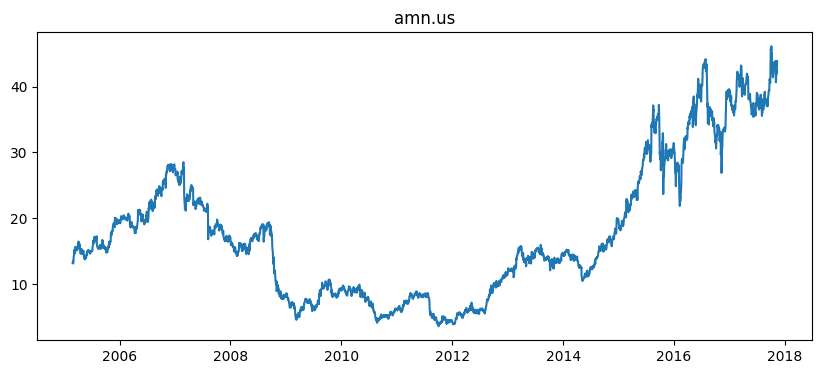

bspm.us.csv: (2106, 7) rows


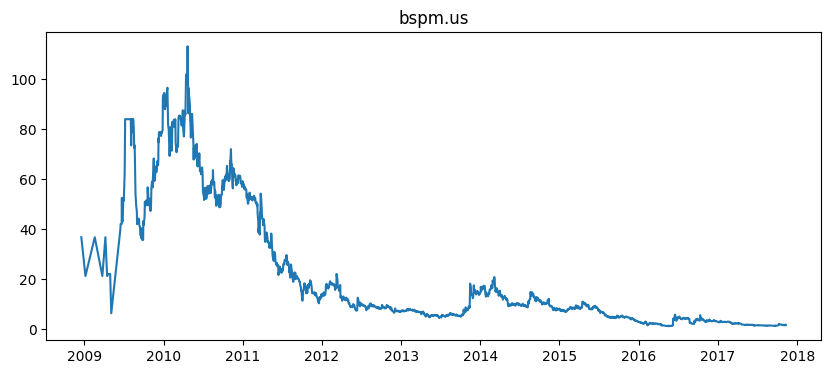

hqcl.us.csv: (2744, 7) rows


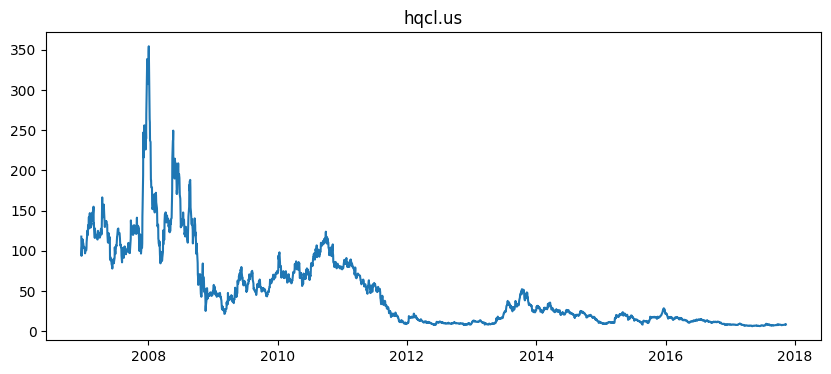

ifn.us.csv: (3201, 7) rows


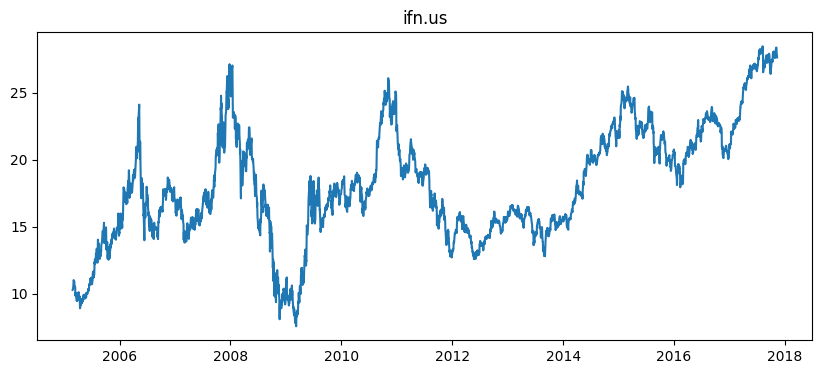

jhme.us.csv: (257, 7) rows


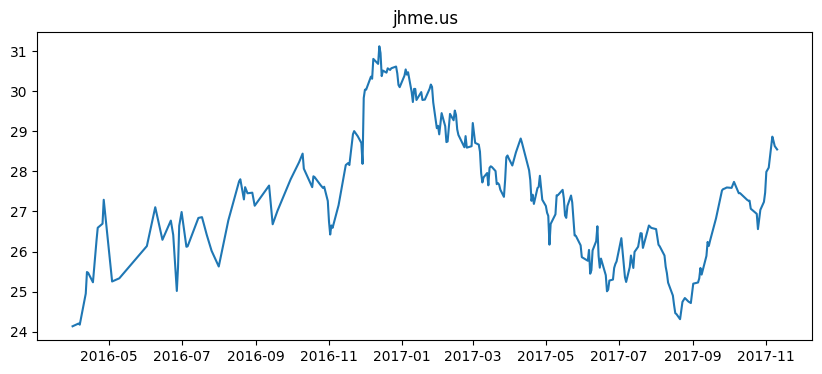

vno_l.us.csv: (1203, 7) rows


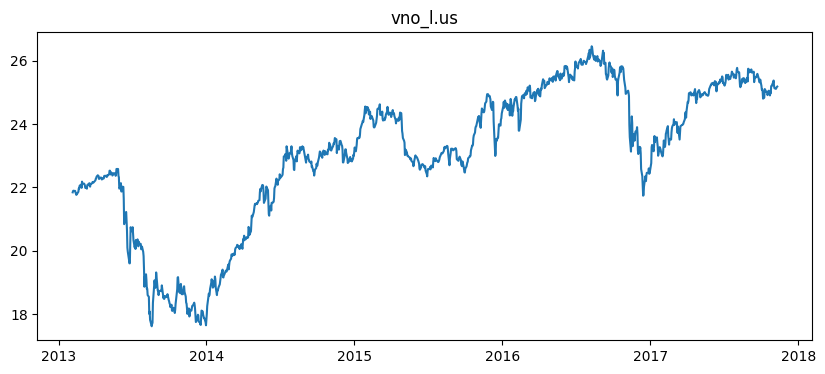

vmo.us.csv: (3201, 7) rows


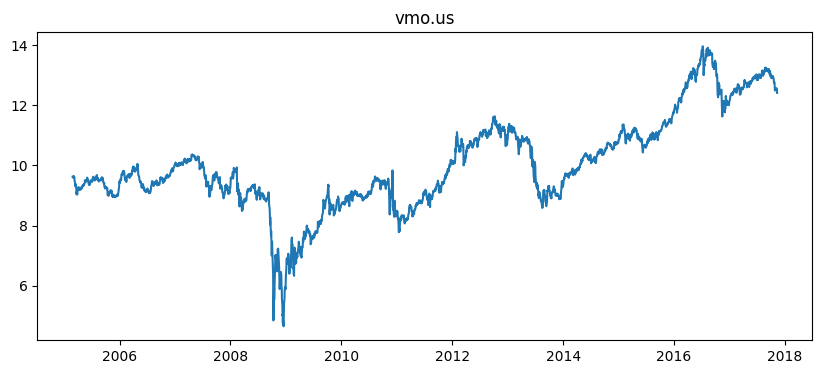

ziop.us.csv: (2966, 7) rows


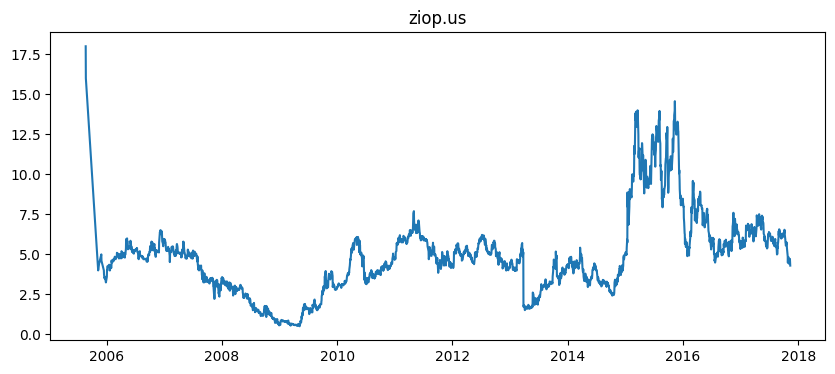

In [86]:
# loop through dfs dictionary of dataframes
for filename, df in dfs.items():
    df['Date'] = pd.to_datetime(df['Date'])
    print(f"{filename}: {df.shape} rows")
    
    plt.figure(figsize=(10, 4))
    plt.plot(df['Date'], df['Close'])
    plt.title(filename[:-4])
    plt.show()



C) Create a function that loads the closing prices from a data file into input and label numpy arrays that are appropriate for training time sequence models to predict a price two days into the future, using a lookback value of your choice.

In [ ]:
import numpy as np
import pandas as pd

def create_sequences(df, lookback=10, future_days=2):
    """
    Convert closing prices to input/label arrays for time series prediction.
    
    Args:
        df: DataFrame with 'Date' and 'Close' columns
        lookback: number of past days to use as input (default: 10)
        future_days: days into future to predict (default: 2)
    
    Returns:
        X: input sequences (n_samples, lookback, 1)
        y: target prices (n_samples,)
    """
    # Use only closing prices, sorted by date
    prices = df.sort_values('Date')['Close'].values
    
    X, y = [], []
    
    # Create sequences
    for i in range(lookback, len(prices) - future_days):
        # Input: past `lookback` days
        X.append(prices[i-lookback:i])
        # Target: price `future_days` ahead
        y.append(prices[i + future_days])
    
    return np.array(X), np.array(y)




amn.us.csv:
  X shape: (3189, 10) (samples, lookback=10, features=1)
  y shape: (3189,) (samples,)
  Sample input: [13.28 13.53 13.17 13.36 13.57]...
  Sample target: 15.07

bspm.us.csv:
  X shape: (2094, 10) (samples, lookback=10, features=1)
  y shape: (2094,) (samples,)
  Sample input: [36.75 21.21 36.75 21.21 36.75]...
  Sample target: 42.00

hqcl.us.csv:
  X shape: (2732, 10) (samples, lookback=10, features=1)
  y shape: (2732,) (samples,)
  Sample input: [117.73   93.809  97.859 103.32  114.34 ]...
  Sample target: 96.92

ifn.us.csv:
  X shape: (3189, 10) (samples, lookback=10, features=1)
  y shape: (3189,) (samples,)
  Sample input: [10.288 10.35  10.479 10.53  10.741]...
  Sample target: 10.26

jhme.us.csv:
  X shape: (245, 10) (samples, lookback=10, features=1)
  y shape: (245,) (samples,)
  Sample input: [24.133 24.202 24.173 24.949 25.488]...
  Sample target: 25.33

vno_l.us.csv:
  X shape: (1191, 10) (samples, lookback=10, features=1)
  y shape: (1191,) (samples,)
  Sample

D) Use the function created in the previous step to load all of the data files into 2d numpy arrays. Concatenate the input arrays and the label arrays. After this step, you should have a single array of sequences for inputs, and a single array of labels.

In [ ]:
import numpy as np

# lookback and future_days from your model design
LOOKBACK = 10
FUTURE_DAYS = 2

# Generate sequences from ALL individual stock files
all_X, all_y = [], []

for filename, df in dfs.items():
    print(f"Processing {filename}")
    
    # Convert dates and create sequences
    df['Date'] = pd.to_datetime(df['Date'])
    X_stock, y_stock = create_sequences(df, lookback=LOOKBACK, future_days=FUTURE_DAYS)
    
    print(f"  {X_stock.shape[0]} sequences created")
    all_X.append(X_stock)
    all_y.append(y_stock)

# 2. Concatenate ALL sequences into single arrays
X_all = np.vstack(all_X)
y_all = np.hstack(all_y)

print(f"\nFINAL ARRAYS:")
print(f"X_all shape: {X_all.shape}  (samples, timesteps={LOOKBACK}, features=1)")
print(f"y_all shape: {y_all.shape}  (samples,)")

print(f"\nFirst sequence example:")
print(f"Input (past {LOOKBACK} days): {X_all[0].flatten()}")
print(f"Target (day {FUTURE_DAYS} ahead): {y_all[0]:.2f}")


Processing amn.us.csv...
  3189 sequences created
Processing bspm.us.csv...
  2094 sequences created
Processing hqcl.us.csv...
  2732 sequences created
Processing ifn.us.csv...
  3189 sequences created
Processing jhme.us.csv...
  245 sequences created
Processing vno_l.us.csv...
  1191 sequences created
Processing vmo.us.csv...
  3189 sequences created
Processing ziop.us.csv...
  2954 sequences created

FINAL ARRAYS:
X_all shape: (18783, 10)  (samples, timesteps=10, features=1)
y_all shape: (18783,)  (samples,)

First sequence example:
Input (past 10 days): [13.28 13.53 13.17 13.36 13.57 14.13 14.6  14.55 15.2  14.72]
Target (day 2 ahead): 15.07


### Modeling 
A) Create and compile a time sequence model using tf.keras.Sequential. Use at least one Conv1d layer, one SimpleRNN layer, and one Dropout layer. Use mean_squared_error for the loss.


B) Train the model on the training data without using a validation split. Calculate and record the training loss.

C) Use the model to make predictions on the validation data. Calculate and record the validation loss. Create plots of the validation data that show the true price as well as the model predictions, with date or index number along the x-axis.

D) Revisit the previous steps to make at least three models in total by changing architecture and hyperparameters.

E) Once you are finished altering hyperparameters, present neatly the training and validation loss along with the plots for each model showing predicted prices and actual prices. Choose the best model by comparing how each model did on training and validation data; provide your reasoning in markdown.

F) With the best model, make predictions on the testing data; calculate the testing loss and present a scatter plot of the predictions along with the true values. 

### Discussion
A) Select the best model based on quantitative metrics and plots. Consider zooming-in on problem areas when comparing performance. Justify your selection using markdown.

B) Use markdown to describe how well you feel your model would work to predict closing stock prices two days into the future. Give a quantitative estimate of the error in the predictions.